In [8]:
from __future__ import annotations
import operator
from typing import TypedDict,List,Annotated
from langgraph.graph import StateGraph,START,END
from langgraph.types import Send
from pydantic import BaseModel, Field
from langchain_mistralai import ChatMistralAI
from langchain_core.messages import SystemMessage,HumanMessage
from dotenv import load_dotenv
load_dotenv()

True

In [9]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(...,description="What to cover")

In [10]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [11]:
class State(TypedDict):
    topic: str
    plan: Plan
    sections: Annotated[List[str], operator.add]
    final: str

In [12]:
model = ChatMistralAI(model_name="mistral-small-2506")

In [13]:
def orchestrator(state: State) -> dict:
    plan = model.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [15]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [16]:
def worker(payload: dict) -> dict:
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title
    section_md = model.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.title}\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()
    return {"sections": [section_md]}

In [ ]:
def reducer(state: State) -> dict:
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    safe_title = title.lower().replace(" ", "_").replace("-", "_")
    filename = safe_title + ".md"
    output_path = Path(__file__).parent / filename if "__file__" in dir() else Path(filename)
    output_path.write_text(final_md, encoding="utf-8")
    print(f"Blog saved to: {output_path.resolve()}")

    return {"final": final_md}


In [18]:
g = StateGraph(State)
g.add_node("orchestrator",orchestrator)
g.add_node("worker",worker)
g.add_node("reducer",reducer)


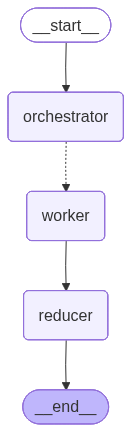

In [19]:
g.add_edge(START,"orchestrator")
g.add_conditional_edges("orchestrator",fanout,["worker"])
g.add_edge("worker","reducer")
g.add_edge("reducer",END)

app = g.compile()
app

In [20]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})

In [21]:
out

{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Understanding Self-Attention: A Comprehensive Guide', tasks=[Task(id=1, title='Introduction to Self-Attention', brief='Explain what self-attention is and its importance in modern machine learning, particularly in the context of natural language processing.'), Task(id=2, title='The Mechanics of Self-Attention', brief='Dive into the technical details of how self-attention works, including the use of queries, keys, and values.'), Task(id=3, title='Applications of Self-Attention', brief='Discuss various applications of self-attention in different fields, such as language translation, text summarization, and more.'), Task(id=4, title='Self-Attention in Transformer Models', brief='Explore how self-attention is utilized in transformer models and why it has become a cornerstone of modern NLP.'), Task(id=5, title='Challenges and Limitations', brief='Address the challenges and limitations of self-attention, including computati